<a href="https://colab.research.google.com/github/rautsahil02/CSL701-38_Machine-Learning-Lab-/blob/main/EXPERIMENT/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [17]:
# TASK 1: Environment Setup and Dataset Loading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Load diabetes.csv
df = pd.read_csv("diabetes.csv")

# Display first 5 records
print("First 5 Records:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

Saving diabetes.csv to diabetes.csv
First 5 Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         floa

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


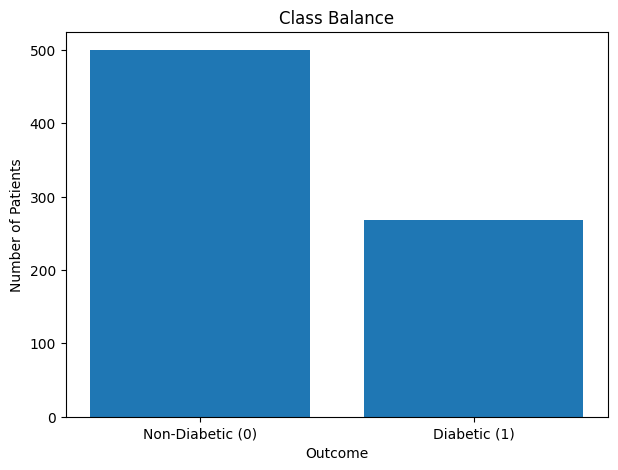

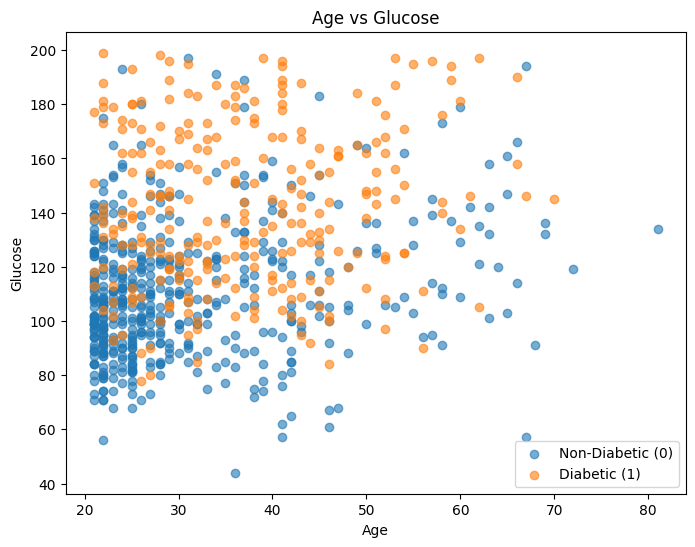

In [20]:
# TASK 2: Exploratory Data Analysis

# Count diabetic and non-diabetic cases
class_counts = df["Outcome"].value_counts().sort_index()

print("Class Counts:")
print(class_counts)

# Calculate percentages
class_percentages = df["Outcome"].value_counts(
    normalize=True
).sort_index() * 100

print("\nClass Percentages:")
print(class_percentages)

# Bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    class_counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Balance")

plt.show()


# Scatter plot: Age vs Glucose
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.6
)

plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    label="Diabetic (1)",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.legend()

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [21]:
# TASK 3: Preprocessing and Handling Missing Values

# Features where zero is invalid
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Check zero values
print("Zero values before replacement:\n")

for column in invalid_features:
    print(column, ":", (df[column] == 0).sum())

# Replace zero with NaN
df[invalid_features] = df[invalid_features].replace(
    0, np.nan
)

# Display missing values
print("\nMissing values after replacing 0 with NaN:")
print(df.isnull().sum())

# Fill missing values using median
for column in invalid_features:
    df[column] = df[column].fillna(
        df[column].median()
    )

# Verify missing values
print("\nMissing values after imputation:")
print(df.isnull().sum())

print("\nFirst 5 rows after preprocessing:")
print(df.head())

Zero values before replacement:

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing 0 with NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

First 5 rows after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2   

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [22]:
# TASK 4: Stratified Train-Test Splitting

# Features
X = df.iloc[:, :8]

# Target
y = df.iloc[:, 8]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

# Check class distribution
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

X Shape: (768, 8)
y Shape: (768,)

Training Data Shape:
(614, 8)

Testing Data Shape:
(154, 8)

Training Class Distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing Class Distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [23]:
# TASK 5: Custom Bootstrap Sampling

def get_bootstrap_sample(X, y):

    # Number of samples
    n = len(X)

    # Random indices with replacement
    indices = np.random.choice(
        n,
        size=n,
        replace=True
    )

    # Bootstrap dataset
    X_bootstrap = X.iloc[indices].copy()
    y_bootstrap = y.iloc[indices].copy()

    return X_bootstrap, y_bootstrap, indices


# Generate bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

print("Original Training Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_bootstrap))

# Find duplicate indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

# Find OOB indices
all_indices = set(range(len(X_train)))
selected_indices = set(bootstrap_indices)

oob_indices = sorted(
    all_indices - selected_indices
)

print("\nNumber of duplicated indices:",
      len(duplicated_indices))

print("Duplicated indices:")
print(duplicated_indices[:20])

print("\nNumber of OOB samples:",
      len(oob_indices))

print("OOB indices:")
print(oob_indices[:20])

Original Training Size: 614
Bootstrap Sample Size: 614

Number of duplicated indices: 164
Duplicated indices:
[ 2  5 12 17 22 27 28 30 33 45 52 54 59 60 61 67 71 72 75 78]

Number of OOB samples: 231
OOB indices:
[0, 1, 4, 6, 7, 9, 10, 13, 15, 19, 23, 24, 26, 31, 32, 34, 36, 37, 39, 41]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [24]:
# TASK 6: Growing the Ensemble of Base Classifiers

# Number of trees
B = 50

# Empty list for models
ensemble = []

# Train 50 decision trees
for i in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create Decision Tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=42 + i
    )

    # Train tree
    tree.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Store tree
    ensemble.append(tree)

print("Number of trees in ensemble:",
      len(ensemble))

Number of trees in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [25]:
# TASK 7: Custom Bagging Prediction

def custom_bagging_predict(ensemble, X_test):

    # Store predictions from all trees
    all_predictions = []

    for model in ensemble:

        predictions = model.predict(X_test)

        all_predictions.append(predictions)

    # Convert to NumPy array
    all_predictions = np.array(
        all_predictions
    )

    # Majority voting
    final_predictions = []

    for i in range(all_predictions.shape[1]):

        # Votes for one test sample
        votes = all_predictions[:, i]

        # Count votes
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        # Majority class
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Predict using custom Bagging
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("First 20 Bagging Predictions:")
print(y_pred_bagging[:20])

First 20 Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


Single Decision Tree
Accuracy : 0.8116883116883117
Precision: 0.7450980392156863
Recall   : 0.7037037037037037
F1-Score : 0.7238095238095238

Confusion Matrix:
[[87 13]
 [16 38]]

Custom Bagging
Accuracy : 0.8701298701298701
Precision: 0.8035714285714286
Recall   : 0.8333333333333334
F1-Score : 0.8181818181818182

Confusion Matrix:
[[89 11]
 [ 9 45]]


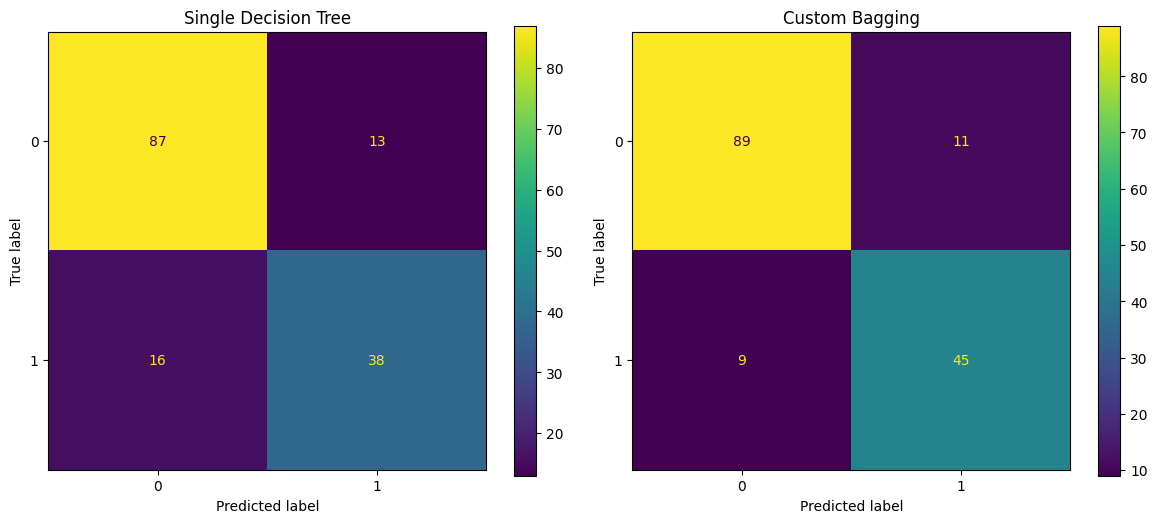

In [26]:
# TASK 8: Single Decision Tree vs Bagging

# Train single Decision Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(
    X_train,
    y_train
)

# Single tree prediction
y_pred_tree = single_tree.predict(
    X_test
)

# Bagging prediction
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# Function to calculate metrics
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nConfusion Matrix:")
    print(cm)

    return cm


# Evaluate single tree
cm_tree = evaluate_model(
    "Single Decision Tree",
    y_test,
    y_pred_tree
)


# Evaluate Bagging
cm_bagging = evaluate_model(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)


# Plot confusion matrices
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[0, 1]
).plot(ax=axes[0])

axes[0].set_title(
    "Single Decision Tree"
)


ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=[0, 1]
).plot(ax=axes[1])

axes[1].set_title(
    "Custom Bagging"
)

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7868518518518519
Custom Bagging AUC: 0.9438888888888888


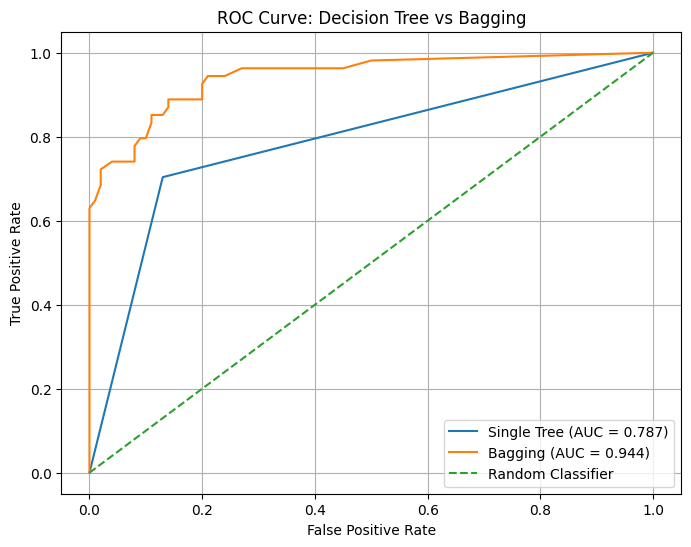

In [27]:
# TASK 9: ROC-AUC Analysis

# Single Decision Tree probabilities
y_prob_tree = single_tree.predict_proba(
    X_test
)[:, 1]


# Store probabilities from every tree
all_probabilities = []

for model in ensemble:

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    all_probabilities.append(
        probabilities
    )


# Convert to NumPy array
all_probabilities = np.array(
    all_probabilities
)


# Average probabilities
y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)


# ROC curve - Single Tree
fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)


# ROC curve - Bagging
fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    y_prob_bagging
)


# AUC
auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


print("Single Decision Tree AUC:",
      auc_tree)

print("Custom Bagging AUC:",
      auc_bagging)


# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Single Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Bagging (AUC = {auc_bagging:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve: Decision Tree vs Bagging"
)

plt.legend()
plt.grid()

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn Bagging Accuracy:
0.8831168831168831

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Accuracy Comparison
Custom Bagging Accuracy: 0.8701298701298701
Scikit-Learn Bagging Accuracy: 0.8831168831168831

Accuracy Difference: 0.012987012987012991


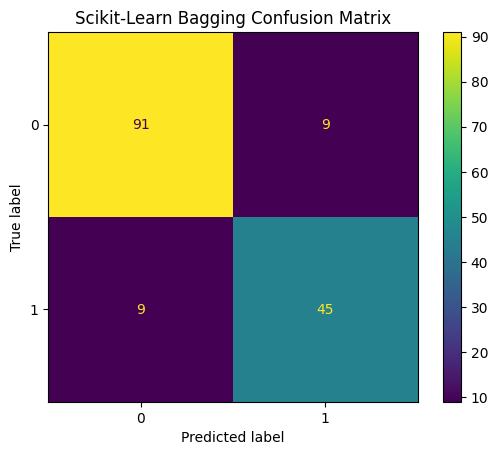

In [28]:
# TASK 10: Validation with Scikit-Learn BaggingClassifier

from sklearn.ensemble import BaggingClassifier

# Base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


# Create Bagging Classifier
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)


# Train
sklearn_bagging.fit(
    X_train,
    y_train
)


# Prediction
y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# Accuracy
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)


# Confusion Matrix
sklearn_cm = confusion_matrix(
    y_test,
    y_pred_sklearn
)


print("Scikit-Learn Bagging Accuracy:")
print(sklearn_accuracy)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(sklearn_cm)


# Custom Bagging accuracy
custom_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

print("\n==============================")
print("Accuracy Comparison")
print("==============================")

print("Custom Bagging Accuracy:",
      custom_accuracy)

print("Scikit-Learn Bagging Accuracy:",
      sklearn_accuracy)


# Difference
difference = abs(
    custom_accuracy -
    sklearn_accuracy
)

print("\nAccuracy Difference:",
      difference)


# Display confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=sklearn_cm,
    display_labels=[0, 1]
).plot()

plt.title(
    "Scikit-Learn Bagging Confusion Matrix"
)

plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?